In [101]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [102]:
base_dir = Path("classified_datasets/pollution")

# 1) Iterate through files and read with pandas
csv_files = sorted(base_dir.rglob("*.csv"))

dataframes = {}
datetime_candidates = {"DateTime", "timeArray", "datetime", "timestamp"}
pollutant_candidates = {"NOx", "NO", "NO2", "PM10", "O3", "CO"}

for fp in csv_files:
    try:
        df = pd.read_csv(fp, low_memory=False)

        # Keep only measurement-like tables (datetime + at least one pollutant metric).
        has_datetime = any(c in df.columns for c in datetime_candidates)
        has_pollutant = any(c in df.columns for c in pollutant_candidates)
        if has_datetime and has_pollutant:
            dataframes[str(fp)] = df
    except Exception as e:
        print(f"Failed: {fp.name} -> {e}")

combined_df = pd.concat(dataframes.values(), ignore_index=True) if dataframes else pd.DataFrame()
print("Files included:", len(dataframes))
print("Combined shape:", combined_df.shape)

Files included: 10
Combined shape: (1089882, 17)


In [ ]:
df = combined_df.copy()

In [104]:
missing_percentages = df.isnull().mean() * 100

# Keep key metadata / pollutant columns even if they are sparse.
preferred_cols = [
    "ID", "DateTime", "timeArray", "Sensor Location Name", "Sensor Location Slug", "Sensor Location",
    "NOx", "NO", "NO2", "PM10", "O3", "CO"
]
protected_cols = set(preferred_cols)

columns_to_drop = [
    c for c in missing_percentages[missing_percentages > 70].index
    if c not in protected_cols
]
df = df.drop(columns=columns_to_drop)

keep_cols = [c for c in preferred_cols if c in df.columns]
if keep_cols:
    df = df[keep_cols]


In [105]:
df.drop_duplicates(inplace=True)

# Standardize timestamps to a regular interval so missing frames can be detected consistently.

In [106]:
datetime_col = "DateTime"

df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
df = df.dropna(subset=[datetime_col]).copy()

df = df.rename(columns={datetime_col: "timeArray"})
df["timeArray"] = df["timeArray"].dt.floor("15min")

# Convert pollutant columns to numeric where possible.
non_numeric_keep = {"ID", "Sensor Location Name", "Sensor Location Slug", "Sensor Location", "timeArray"}
for col in df.columns:
    if col in non_numeric_keep:
        continue
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Keep pollution signal columns and location metadata for spatial analysis.
pollution_cols = [c for c in ["NOx", "NO", "NO2", "PM10", "O3", "CO"] if c in df.columns]

location_cols = [
    c for c in ["ID", "Sensor Location Name", "Sensor Location Slug", "Sensor Location"]
    if c in df.columns
]

df = df[["timeArray"] + location_cols + pollution_cols]
df.reset_index(drop=True, inplace=True)

In [107]:
# Split pollution dataset by location.
location_key = "Sensor Location Name" if "Sensor Location Name" in df.columns else "Sensor Location"

location_datasets = {
    str(loc): grp.sort_values("timeArray").reset_index(drop=True)
    for loc, grp in df.groupby(location_key, dropna=False)
}

print(f"Created {len(location_datasets)} location datasets using '{location_key}'.")
print("Locations:", list(location_datasets.keys())[:10])

# Example: access one location dataset
location_datasets["Bath Guildhall"].head(5)

Created 5 location datasets using 'Sensor Location Name'.
Locations: ['Bath Guildhall', 'London Road AURN', 'London Road Enclosure', 'Royal Victoria Park', 'Windsor Bridge']


,timeArray,ID,Sensor Location Name,Sensor Location Slug,Sensor Location,NOx,NO,NO2,PM10,O3,CO
0,2014-01-08 00:00:00,5130c7ee2a14182e406b8c5fad80ced1,Bath Guildhall,guildhall,"(51.382218916047, -2.359034027552)",4.5,0.0,6.5,NaN,NaN,0.2
1,2014-01-08 00:15:00,6d247bcd5422d283a27db4bbe11e3910,Bath Guildhall,guildhall,"(51.382218916047, -2.359034027552)",4.0,0.0,5.5,NaN,NaN,0.2
2,2014-01-08 00:30:00,fbf3a36a3343656e1d5144868fd92b84,Bath Guildhall,guildhall,"(51.382218916047, -2.359034027552)",2.0,0.0,4.0,NaN,NaN,0.2
3,2014-01-08 00:45:00,b9a9d22ea343c20a971dde54c750765c,Bath Guildhall,guildhall,"(51.382218916047, -2.359034027552)",2.0,0.0,4.0,NaN,NaN,0.2
4,2014-01-08 01:00:00,acc14858b34c19ff6f593b5675c7f0b4,Bath Guildhall,guildhall,"(51.382218916047, -2.359034027552)",3.0,0.0,4.5,NaN,NaN,0.2


In [108]:
location_df = df[["Sensor Location Name", "Sensor Location"]].drop_duplicates()


location_df[['lat', 'lon']] = location_df['Sensor Location'].str.strip("()").str.split(', ', expand=True)
location_df[['lat', 'lon']] = location_df[['lat', 'lon']].astype(float)

In [109]:
# Quick spatial diagnostics for transferability of weather-based PM10 prediction
import math
import itertools

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dlon / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))

pairs = []
for (n1, la1, lo1), (n2, la2, lo2) in itertools.combinations(
    location_df[["Sensor Location Name", "lat", "lon"]].itertuples(index=False, name=None),
    2,
):
    pairs.append((n1, n2, haversine_km(la1, lo1, la2, lo2)))

pairwise_df = pd.DataFrame(pairs, columns=["sensor_a", "sensor_b", "distance_km"])

print("Distance range between Bath pollution sensors (km):")
print(pairwise_df["distance_km"].describe()[["min", "max", "mean"]])

display(pairwise_df.sort_values("distance_km", ascending=False).head(10))

Distance range between Bath pollution sensors (km):
min     0.039613
max     2.150023
mean    1.251476
Name: distance_km, dtype: float64


,sensor_a,sensor_b,distance_km
6,London Road AURN,Windsor Bridge,2.150023
8,London Road Enclosure,Windsor Bridge,2.117135
3,Bath Guildhall,Windsor Bridge,1.566636
5,London Road AURN,Royal Victoria Park,1.374566
7,London Road Enclosure,Royal Victoria Park,1.339718
2,Bath Guildhall,Royal Victoria Park,1.049155
0,Bath Guildhall,London Road AURN,1.046355
1,Bath Guildhall,London Road Enclosure,1.038225
9,Royal Victoria Park,Windsor Bridge,0.793337
4,London Road AURN,London Road Enclosure,0.039613


- Weather signal is likely transferable across Bath at a broad scale (distances are short).
- PM10 also has strong local effects (traffic/street-canyon), so location-specific calibration is still recommended.
- Best practice: include location ID in the model, then validate error per sensor.

# Missing data handling and imputation

In [72]:
for i in location_datasets:
    print(location_datasets[i].shape)

(49098, 11)
(49586, 11)
(12320, 11)
(2864, 11)
(12416, 11)


In [76]:
for i in location_datasets:
    print(i)
    print(location_datasets[i].isna().sum())
    print("")

Bath Guildhall
timeArray                   0
ID                          0
Sensor Location Name        0
Sensor Location Slug        0
Sensor Location             0
NOx                         0
NO                          0
NO2                         0
PM10                    49098
O3                      49098
CO                      30508
dtype: int64

London Road AURN
timeArray                   0
ID                          0
Sensor Location Name        0
Sensor Location Slug        0
Sensor Location             0
NOx                         0
NO                          0
NO2                         0
PM10                    49586
O3                      49586
CO                      49586
dtype: int64

London Road Enclosure
timeArray                   0
ID                          0
Sensor Location Name        0
Sensor Location Slug        0
Sensor Location             0
NOx                         0
NO                          0
NO2                         0
PM10              

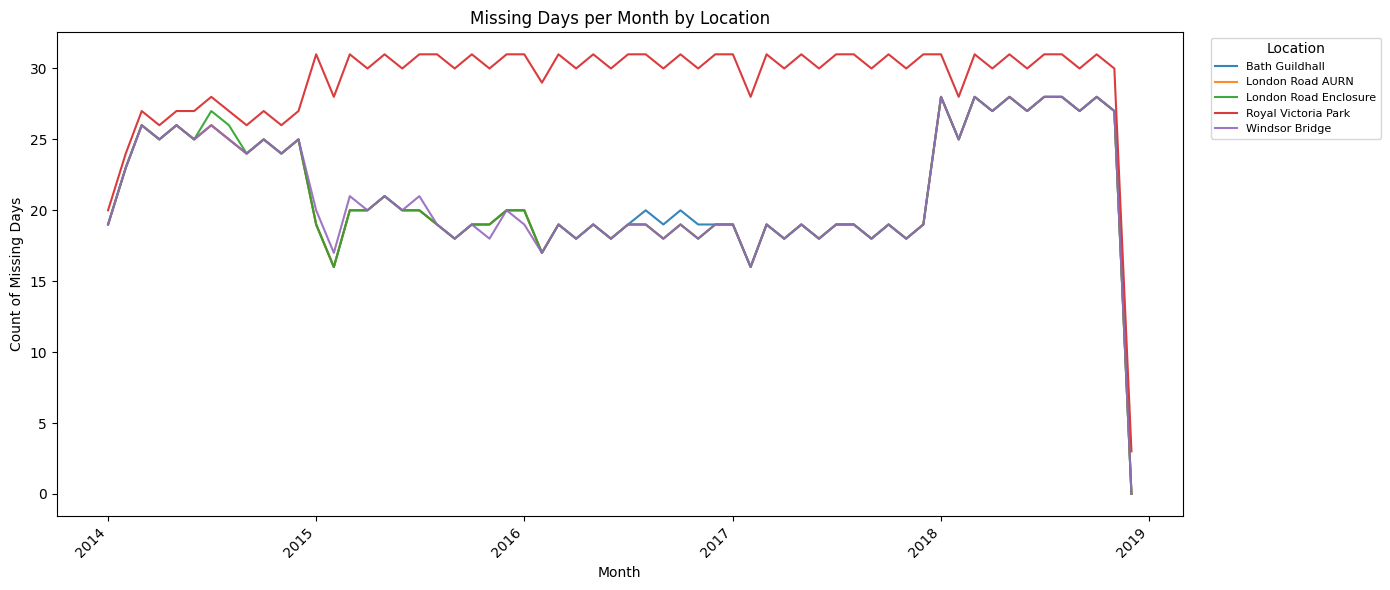

In [ ]:
if "location_datasets" not in globals():
    raise ValueError("Run the location split cell first to create 'location_datasets'.")

all_present_days = pd.to_datetime(df["timeArray"].dt.normalize().unique())
all_present_days = pd.DatetimeIndex(all_present_days).sort_values()

all_days = pd.date_range(
    start=all_present_days.min(),
    end=all_present_days.max(),
    freq="D"
)

plt.figure(figsize=(14, 6))

for loc_name, loc_df in location_datasets.items():
    present_days = pd.to_datetime(loc_df["timeArray"].dt.normalize().unique())
    present_days = pd.DatetimeIndex(present_days).sort_values()

    day_status = pd.Series(False, index=all_days, name="present")
    day_status.loc[present_days] = True
    monthly_missing = (~day_status).resample("MS").sum()

    plt.plot(
        monthly_missing.index,
        monthly_missing.values,
        label=str(loc_name),
        linewidth=1.5,
        alpha=0.9,
    )

plt.title("Missing Days per Month by Location")
plt.ylabel("Count of Missing Days")
plt.xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


we can see that some of teh more important metrics that might be harder to impute. pm10 there is papers about it using weatehr data, wind spee, humidity ect(https://www.sciencedirect.com/science/article/pii/S1877050925028248) with rather good results, NOx values are closely linked to traffic and not many data is missing so shouldn't be an issue, co and o3 might be bit harder to impute as there are a lot missing. for o3 I found this, meaning it can be done (https://www.mdpi.com/2071-1050/17/20/9211) for co the results are a bit worst but doable with humidity, windspeed, NO values, and o3 according to this paper in malaysia (https://www.sciencedirect.com/science/article/pii/S2352186423003838#sec0095)


Another large issue is missing days, but it would be not feasable to impute whole weeks 

# Detect regular interval gaps, excluding very large holes.

In [ ]:
df = df.sort_values("timeArray").reset_index(drop=True)
df = df.interpolate("linear")

In [ ]:
df["timeArray"] = pd.to_datetime(df["timeArray"])
df["gap_size"] = df["timeArray"].diff()

# Pollution data is mostly 15-minute granularity.
small_gap_limit = pd.Timedelta(minutes=30)
medium_gap_limit = pd.Timedelta(hours=2)

gaps_summary = df[
    (df["gap_size"] > pd.Timedelta(minutes=15))
    & (df["gap_size"] < pd.Timedelta(days=1))
]

print(gaps_summary["gap_size"].value_counts())


gap_size
0 days 01:00:00    104
0 days 00:45:00      2
0 days 11:15:00      2
0 days 10:00:00      1
0 days 13:00:00      1
Name: count, dtype: int64


In [56]:
df = df.set_index("timeArray").sort_index()

# 2. Resample to create the uniform 15-minute grid (inserts missing timestamps).
df_filled_gaps = df.resample("15min").asfreq()

# 3. Interpolate only numeric features across shorter gaps.
# limit=20 -> fill at most 5 hours within a missing run.
numeric_cols = df_filled_gaps.select_dtypes(include="number").columns
df_filled_gaps[numeric_cols] = df_filled_gaps[numeric_cols].interpolate(method="linear", limit=20)

# 4. Keep full timeline so large gaps remain un-imputed and visible.
df_final = df_filled_gaps.copy()

In [57]:
df_final = df_final.drop(columns=["gap_size"], errors="ignore")
df_final

,NOx,NO,NO2,PM10,O3,CO
timeArray,,,,,,
2014-01-08 00:00:00,17.214075,8.55455,9.897575,14.711950,12.500,-0.0375
2014-01-08 00:15:00,10.349850,3.60000,7.500000,14.681413,13.250,0.2000
2014-01-08 00:30:00,11.399900,5.35000,7.049950,14.650875,13.000,0.2000
2014-01-08 00:45:00,11.399900,5.35000,7.049950,14.620337,13.000,0.2000
2014-01-08 01:00:00,11.748675,5.08060,7.672200,14.589800,12.500,-0.0500
...,...,...,...,...,...,...
2018-12-03 22:45:00,18.449950,5.70000,12.799950,17.122813,21.625,0.0000
2018-12-03 23:00:00,21.362350,7.76870,13.618650,18.740250,21.625,0.0000
2018-12-03 23:15:00,13.600000,3.74995,9.849900,18.740250,21.625,0.0000
